# WASP2026 draft: mean colour value

A single panel, for one question: **what is the mean value of the data along
the colour-axis**. It is the figure this notebook used to build from the
`jcdl_followup` run -- the one marked "THIS ONE BELOW IS THE ONE WE USE IN THE
PAPER" -- reduced to one question and repointed at this project. That code has
been removed; it is in git history if it is ever wanted back.

* one stepped histogram per low-tier model, as in the paper figure
* x-axis is **sSMAPE**, the signed symmetric percentage error used there:

      sSMAPE = (LMM - GT) / ((|LMM| + |GT|) / 2)

  It is bounded on [-2, 2]: 0 is exact, negative means the model
  under-estimated, +/-2 means it was wrong by more than the scale of the answer
  (or got the sign wrong).  Bounded is the point -- the colour values span many
  orders of magnitude across figures, so a plain relative error would be
  unplottable.

Self-contained: no `parse_lmm_output_utils` / `results_plotting_utils`, which
are not part of this repo.


In [1]:
# ======================== CONFIG ========================
# One row of the figure per run: (row label, directory of per-model pickles).
# All three cover the SAME 150 figures, so the rows differ only by how the page
# was treated before it was sent.
runs = [
    ('original',      '~/astro_sky_image_vqa/LMM_outputs_n150/'),
    ('archive',       '~/astro_sky_image_vqa/LMM_outputs_n150_archive/'),
    ('archive-light', '~/astro_sky_image_vqa/LMM_outputs_n150_archive_light/'),
]

# The full-strength 'archive' aging may not make the paper -- this drops that
# row without touching anything else.
show_archive = False

# Same switch for the archive-light row.  Set False to show ONLY the original
# (unaged) figures -- useful while an aged run is still in progress, since a
# half-finished row otherwise plots as a mostly-empty panel and drags the
# pooled per-category counts around.
show_archive_light = True


qa_jsons_dir = '~/astro_sky_image_vqa/VQA_full/qa_jsons/'
fig_out_dir  = '~/Dropbox/WASP2026/paper_figures/'

# model subdirectory -> (display name, colour).  Colours are the low-tier ones
# from the paper figure.
model_spec = {
    'chatgpt_api':  ('GPT',    'darkblue'),
    'gemini':       ('Gemini', 'orange'),
    'claude_haiku': ('Claude', 'cyan'),
}

# One BLOCK of rows per question, matched on the rendered question text.
# Each block gets the full set of runs, stacked, so the figure reads as
#   mean   : original / archive / archive-light
#   median : original / archive / archive-light
# One FIGURE per question -- the mean under the heading at the top, the median
# under "Median calculation" further down.  Each is (label, text to match in the
# rendered question, y-axis tag, output filename).
questions = [
    ('mean colour value',   ('mean value', 'color-axis'),
     r'$\mathrm{\langle data_{color} \rangle}$',   'mean_color_ssmape.pdf'),
    ('median colour value', ('median value', 'color-axis'),
     r'$\mathrm{median}(data_{color})$',            'median_color_ssmape.pdf'),
    # These two are asked of SKY panels only -- a contour figure has no angular
    # extent -- so their histograms cover 100 figures per run, not 150.
    ('angular width',       ('angular width',),
     r'$\Delta\alpha\cos\delta$ [arcmin]',         'angular_width_ssmape.pdf'),
    ('angular height',      ('angular height',),
     r'$\Delta\delta$ [arcmin]',                    'angular_height_ssmape.pdf'),
]

# restrict to one figure category, or None to pool all three
# ('contour', 'sky-gmm', 'sky-real')
only_category = None

# histogram / axes -- same look as the paper figure
# The paper used 40 bins, which needs a few hundred points per model to look
# like a distribution.  On the 15-figure stand-in run each bar is one figure, so
# this is dialled down; put it back to 40 for the full run.
nbins      = 17
xlim       = (-2.05, 2.05)
ylim       = None          # None -> autoscale
hist_thick = 3
show_zero_line = False      # mark the exact answer

# Rows are packed close together and only the BOTTOM one keeps its x-axis
# label and tick labels, since every row shares the same sSMAPE axis.
row_gap       = 0.06    # vertical space between rows, as a fraction of row height
row_height_in = 2.4     # height of one row
fig_width_in  = 6.8

# True  -> legend sits INSIDE the top panel, which costs no figure width.
#          'best' lets matplotlib score every candidate spot against the drawn
#          lines and pick the emptiest, so it moves per figure rather than
#          landing on a histogram in one of them.
# False -> legend outside on the right, as the original paper figure had it.
legend_inside     = True
legend_loc        = 'best'   # or 'upper left', 'upper center', ... when inside
legend_framealpha = 0.85     # slightly see-through, so nothing is fully hidden


In [2]:
import os, json, glob, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Response parsing lives in models/utils/parse_lmm_output_utils.py, copied from
# the LLM_VQA_MultiPanel project, so both figure notebooks parse identically.
# It tolerates what models actually return: a renamed key (Claude answers
# 'plot_types' for 'plot types'), trailing commas, single quotes, merged
# answer/explanation objects.  as_float() additionally rewrites math notation
# ('1.2^-5', unicode minus) before the float() -- a no-op on the n150 run
# (0 of 3150 answers changed) but a guard for future runs.
import sys as _sys
_sys.path.insert(0, os.path.abspath(os.path.join('..')))
from utils.parse_lmm_output_utils import (answer_for, expected_key_from_format,
                                          ground_truth, as_float)

# run paths are expanded per row in the PARSE cell
qa_jsons_dir = os.path.expanduser(qa_jsons_dir)
fig_out_dir  = os.path.expanduser(fig_out_dir)
os.makedirs(fig_out_dir, exist_ok=True)


_cat_cache = {}

def figure_category(vqa_id):
    """contour / sky-gmm / sky-real, from the figure's own data."""
    if vqa_id not in _cat_cache:
        with open(os.path.join(qa_jsons_dir, vqa_id + '_qa.json')) as f:
            d = json.loads(json.load(f))
        p = d['plot0']
        _cat_cache[vqa_id] = ('contour' if p['type'] == 'contour'
                              else 'sky-gmm' if p.get('distribution') == 'gmm'
                              else 'sky-real')
    return _cat_cache[vqa_id]


def ssmape(lmm, gt):
    """Signed symmetric percentage error, bounded on [-2, 2]."""
    denom = (np.abs(lmm) + np.abs(gt)) / 2.0
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(denom > 0, (lmm - gt) / denom, np.nan)


In [3]:
# ======================== PARSE ========================
# One block per question, one row per run within it.  All runs cover the same
# 150 figures, so a difference between rows is a difference in how the page was
# degraded rather than a different sample.
_hidden = set()
if not show_archive:
    _hidden.add('archive')
if not globals().get('show_archive_light', True):
    _hidden.add('archive-light')
active_runs = [(lab, d) for lab, d in runs if lab not in _hidden]
if not active_runs:
    raise ValueError('every run is hidden -- turn one of the show_* flags back on')

rows = []
for run_label, run_path in active_runs:
    run_path = os.path.expanduser(run_path)
    for mdir, (mname, _) in model_spec.items():
        pkls = sorted(glob.glob(os.path.join(run_path, mdir, '*_qa.pickle')))
        if not pkls:
            print('[WARN] no pickles in', os.path.join(run_path, mdir))
            continue
        for fp in pkls:
            vqa_id = os.path.basename(fp).removesuffix('_qa.pickle')
            with open(fp, 'rb') as f:
                payload = pickle.load(f)
            qa_list = payload[0] if isinstance(payload, (list, tuple)) else payload
            for e in qa_list:
                q = (e.get('question') or '').lower()
                for qlabel, qmatch, _, _fn in questions:
                    if all(m in q for m in qmatch):
                        rows.append({'question': qlabel, 'run': run_label,
                                     'model': mname, 'vqa_id': vqa_id,
                                     'category': figure_category(vqa_id),
                                     'GT': as_float(ground_truth(e)),
                                     'LMM': as_float(answer_for(
                                         e.get('raw answer') or e.get('Response'),
                                         expected_key_from_format(e.get('format'))))})
                        break

dfmean = pd.DataFrame(rows)
if only_category is not None:
    dfmean = dfmean[dfmean['category'] == only_category]
dfmean['sSMAPE'] = ssmape(dfmean['LMM'].values, dfmean['GT'].values)

print('questions:', ', '.join(q[0] for q in questions))
print('rows per question:', ', '.join(lab for lab, _ in active_runs))
print()
print('UNPARSEABLE answers (no usable number came back; dropped from the histogram):')
unp = (dfmean.assign(unparseable=dfmean['LMM'].isna())
             .groupby(['question', 'run', 'model'])['unparseable'].agg(['sum', 'count']))
unp['pct'] = 100.0 * unp['sum'] / unp['count']
unp.columns = ['unparseable', 'answers', '%']
print(unp.to_string(float_format=lambda v: '%.1f' % v))
print()
print('sSMAPE, over the answers that did parse:')
print(dfmean.groupby(['question', 'run', 'model'])['sSMAPE']
      .describe()[['count', 'mean', '50%']].round(3).to_string())


questions: mean colour value, median colour value, angular width, angular height
rows per question: original, archive-light

UNPARSEABLE answers (no usable number came back; dropped from the histogram):
                                          unparseable  answers    %
question            run           model                            
angular height      archive-light Claude            0      100  0.0
                                  GPT               1      100  1.0
                                  Gemini            0      100  0.0
                    original      Claude            0      100  0.0
                                  GPT               0      100  0.0
                                  Gemini            0      100  0.0
angular width       archive-light Claude            0      100  0.0
                                  GPT               6      100  6.0
                                  Gemini            0      100  0.0
                    original      Claude         

## The exact questions behind each figure

What was actually sent to the models, pulled from the run pickles rather than


In [4]:
# ============ the exact wording behind each question ============
# Printed from the run pickles, not retyped, so this cannot drift from what was
# actually asked.  Driven by the `questions` config above, so adding a question
# there adds it here too.  Each entry carries the pieces separately (persona,
# context, question, format, reasoning) and the assembled `prompt` sent to the
# API.

_found = {q[0]: None for q in questions}
_probe_run = os.path.expanduser(active_runs[0][1])
for _fp in sorted(glob.glob(os.path.join(_probe_run, list(model_spec)[0], '*_qa.pickle'))):
    with open(_fp, 'rb') as _f:
        _payload = pickle.load(_f)
    _qa = _payload[0] if isinstance(_payload, (list, tuple)) else _payload
    for _e in _qa:
        _q = (_e.get('question') or '').lower()
        for _lab, _match, _, _ in questions:
            if _found[_lab] is None and all(_m in _q for _m in _match):
                _found[_lab] = _e
    if all(v is not None for v in _found.values()):
        break

for _lab, _e in _found.items():
    print('=' * 78)
    print(_lab)
    print('=' * 78)
    if _e is None:
        print('  (no example found in this run)\n')
        continue
    print('  SIMPLE (the question alone, as matched in the parse above):')
    print('    %s' % _e.get('question'))
    print()
    _ctx = (_e.get('context') or '').strip()
    print('  CONTEXT:')
    print('    %s' % (_ctx or '(none)'))
    print()
    print('  ANSWER FORMAT:')
    print('    %s' % (_e.get('format') or '').strip())
    print()
    print('  GROUND TRUTH (this figure):')
    print('    %r' % _e.get('A'))
    print()
    print('  FULL PROMPT as sent:')
    print('    %s' % _e.get('prompt'))
    print()


mean colour value
  SIMPLE (the question alone, as matched in the parse above):
    What is the mean value of the data along the color-axis in this figure? 

  CONTEXT:
    (none)

  ANSWER FORMAT:
    Please format the output as a json as {"mean color":""} for this figure, where the "mean color" value should be a float, calculated from the data values used to create the plot.

  GROUND TRUTH (this figure):
    108.42155193676884

  FULL PROMPT as sent:
    I am going to show you an image. Now, what is the mean value of the data along the color-axis in this figure?  Please format the output as a json as {"mean color":""} for this figure, where the "mean color" value should be a float, calculated from the data values used to create the plot. In addition to providing your answer, please provide your reasoning.  Include this as a separate JSON snippet formatted as {"explanation":""} and fill in your reasoning as a string.  Your answer should only include the answer JSON and the explanatio

wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/mean_color_ssmape.pdf

unparseable (dropped from these histograms):
                      unparseable  answers    %
run           model                            
archive-light Claude            0      150  0.0
              GPT              23      150 15.3
              Gemini            4      150  2.7
original      Claude            0      150  0.0
              GPT              16      150 10.7
              Gemini            1      150  0.7


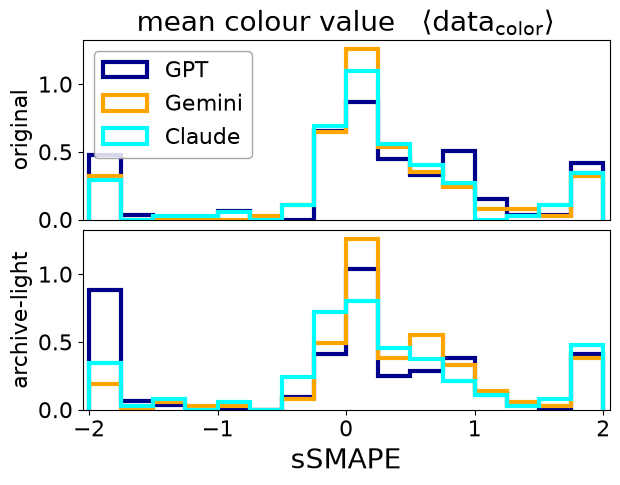

In [5]:
# ======================== PLOT ========================
fontsize        = 20
tick_fontsize   = 16
legend_fontsize = 16
rowlabel_fontsize = 16

bins = np.linspace(-2, 2, nbins)
row_labels = [lab for lab, _ in active_runs]


def plot_question(qlabel, show_legend=True):
    """
    One figure for one question: a row per run, stacked tight, x-axis label and
    tick labels only on the bottom row since every row shares the same axis.
    """
    entry = next(q for q in questions if q[0] == qlabel)
    _, _, qaxis, out_file = entry
    nrows = len(row_labels)

    fig, axes = plt.subplots(nrows, 1, sharex=True,
                             figsize=(fig_width_in, row_height_in * nrows),
                             gridspec_kw={'hspace': row_gap})
    axes = np.atleast_1d(axes)

    for i, (ax, rlab) in enumerate(zip(axes, row_labels)):
        last = (i == nrows - 1)
        sel = dfmean[(dfmean['question'] == qlabel) & (dfmean['run'] == rlab)]
        for mdir, (mname, color) in model_spec.items():
            vals = sel.loc[sel['model'] == mname, 'sSMAPE'].values
            vals = vals[np.isfinite(vals)]
            if len(vals) == 0:
                continue
            ax.hist(vals, bins=bins, density=True, label=mname,
                    color=color, edgecolor=color, linewidth=hist_thick,
                    histtype='step')
        if show_zero_line:
            ax.axvline(0.0, color='gray', linestyle='--', linewidth=2, zorder=0)
        ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)
        ax.set_ylabel(rlab, fontsize=rowlabel_fontsize)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        if last:
            ax.set_xlabel('sSMAPE', fontsize=fontsize)
        else:
            ax.set_xlabel('')
            plt.setp(ax.get_xticklabels(), visible=False)
            ax.tick_params(axis='x', length=0)

    ttl = '%s   %s' % (qlabel, qaxis)
    if only_category is not None:
        ttl += '  (%s)' % only_category
    axes[0].set_title(ttl, fontsize=fontsize)

    if show_legend:
        if legend_inside:
            axes[0].legend(loc=legend_loc, fontsize=legend_fontsize,
                           frameon=True, framealpha=legend_framealpha,
                           edgecolor='0.6')
        else:
            axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                           fontsize=legend_fontsize, frameon=False)

    out_path = os.path.join(fig_out_dir, out_file)
    fig.savefig(out_path, bbox_inches='tight')
    print('wrote', out_path)

    # the counts behind this particular figure
    sel = dfmean[dfmean['question'] == qlabel]
    unp = (sel.assign(unparseable=sel['LMM'].isna())
              .groupby(['run', 'model'])['unparseable'].agg(['sum', 'count']))
    unp['pct'] = 100.0 * unp['sum'] / unp['count']
    unp.columns = ['unparseable', 'answers', '%']
    print()
    print('unparseable (dropped from these histograms):')
    print(unp.to_string(float_format=lambda v: '%.1f' % v))
    return fig


fig = plot_question('mean colour value')


## Median calculation

wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/median_color_ssmape.pdf

unparseable (dropped from these histograms):
                      unparseable  answers   %
run           model                           
archive-light Claude            0      150 0.0
              GPT               1      150 0.7
              Gemini            0      150 0.0
original      Claude            0      150 0.0
              GPT               1      150 0.7
              Gemini            1      150 0.7


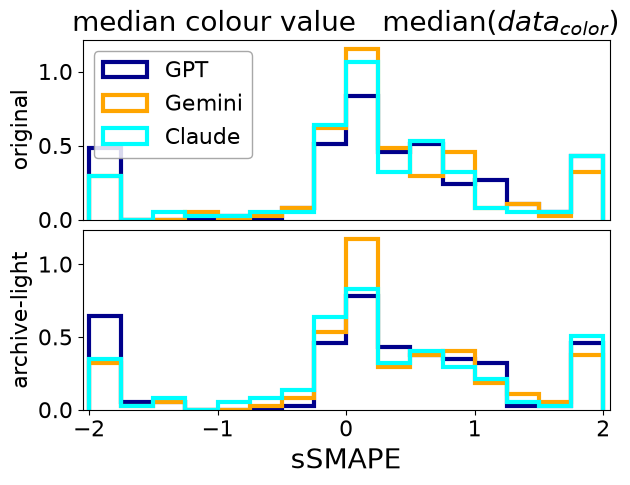

In [6]:
# The same set of plots, for the median colour question.
fig_median = plot_question('median colour value')


## Angular width


wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/angular_width_ssmape.pdf

unparseable (dropped from these histograms):
                      unparseable  answers   %
run           model                           
archive-light Claude            0      100 0.0
              GPT               6      100 6.0
              Gemini            0      100 0.0
original      Claude            0      100 0.0
              GPT               7      100 7.0
              Gemini            0      100 0.0


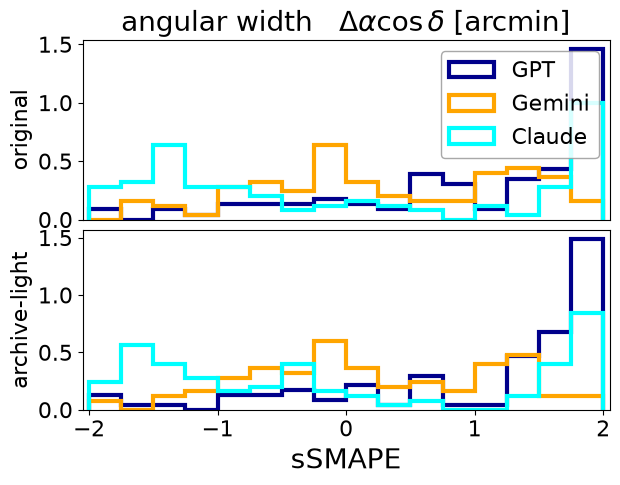

In [7]:
# The same set of plots, for the angular WIDTH question.
# Sky panels only -- contour figures are not asked this, so n is 100 per run.
fig_width_q = plot_question('angular width')


## Angular height


wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/angular_height_ssmape.pdf

unparseable (dropped from these histograms):
                      unparseable  answers   %
run           model                           
archive-light Claude            0      100 0.0
              GPT               1      100 1.0
              Gemini            0      100 0.0
original      Claude            0      100 0.0
              GPT               0      100 0.0
              Gemini            0      100 0.0


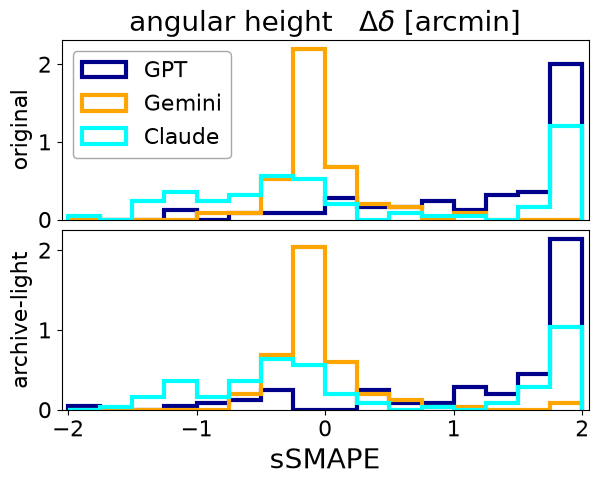

In [8]:
# The same set of plots, for the angular HEIGHT question.
fig_height_q = plot_question('angular height')


## Angular height log-ratio

wrote /Users/jnaiman/Dropbox/WASP2026/paper_figures/angular_height_logratio.pdf

log-ratio summary (non-positive predictions cannot be logged and are excluded, counted separately from unparseable):
          run  model  answers  unparseable  non-positive  plotted  median dex  over %  under %  within 2x %  within 10x %  >+1 dex %  <-1 dex %
     original    GPT      100            0             0      100        1.18   91.00     9.00        18.00         48.00      52.00       0.00
     original Gemini      100            0             0      100       -0.04   28.00    72.00        94.00        100.00       0.00       0.00
     original Claude      100            0             0      100       -0.07   43.00    57.00        40.00         67.00      32.00       1.00
archive-light    GPT      100            1             1       98        1.23   87.76    12.24        15.31         37.76      62.24       0.00
archive-light Gemini      100            0             0      100       -0.04   27

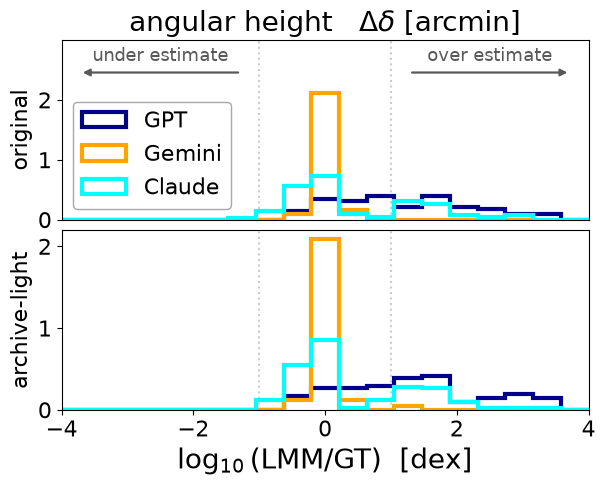

In [10]:
# ============== ANGULAR HEIGHT: log-ratio instead of sSMAPE ==============
# Why this question gets a second metric.
#
# sSMAPE is bounded at +/-2.  That is a virtue for the colour questions -- it
# keeps a near-zero ground truth from blowing the score up -- but a liability
# here: the angular ground truth spans five decades (0.02 .. 1770 arcmin on the
# n150 run) and the models are wrong by more than 10x on most answers, so the
# scores pile up against the bound.  Measured on that run, half the answers sit
# beyond |sSMAPE| = 1.8 and a quarter are pinned past 1.95, which makes a
# prediction 12x too large indistinguishable from one 80,000x too large.
#
# log10(LMM/GT) does not saturate, and it is symmetric in multiplicative terms:
# 2x too large is +0.30 dex, 2x too small is -0.30 dex.  Plain relative error,
# (GT - LMM)/GT, is NOT symmetric -- bounded at 1 for any undershoot but
# unbounded for overshoot, so the same 10x error scores +0.90 or -9.00 purely
# by direction, and the mean is then dominated by a handful of overshoots.
#
# It is defined only where both values are positive.  That exclusion is counted
# and printed below rather than left implicit.

#logratio_xlim      = (-5.0, 5.0)   # dex; the n150 run spans about -2.2 .. +4.9
logratio_xlim      = (-4.0, 4.0)   # dex; the n150 run spans about -2.2 .. +4.9
logratio_nbins     = 20
show_factor_guides = True          # light marks at a factor of ten either way
factor_guides      = (-1.0, 1.0)   # where those marks sit, in dex

# Arrows naming which direction is which.  Placed in the space OUTSIDE the
# factor guides, with positions read from `factor_guides` and `logratio_xlim`,
# so moving a guide or widening the axis moves them too rather than leaving
# them stranded on top of a line.
show_direction_arrows = True
arrow_row        = 0       # which run row carries them (0 = top)
arrow_y_frac     = 0.82    # height within the panel, in axes fractions
arrow_headroom   = 1.35    # y-limit padding so they clear the tallest bar
arrow_color      = '0.35'
arrow_fontsize   = 13


def logratio(lmm, gt):
    """log10(LMM / GT); NaN where either value is missing or non-positive."""
    lmm = np.asarray(lmm, dtype=float)
    gt  = np.asarray(gt,  dtype=float)
    out = np.full(lmm.shape, np.nan)
    ok = np.isfinite(lmm) & np.isfinite(gt) & (lmm > 0) & (gt > 0)
    out[ok] = np.log10(lmm[ok] / gt[ok])
    return out


dfmean['logratio'] = logratio(dfmean['LMM'].values, dfmean['GT'].values)


def _draw_direction_arrows(ax):
    """
    "under estimate" / "over estimate" arrows, in the clear space beyond the
    factor guides.

    Positions come from `factor_guides` and `logratio_xlim` rather than being
    hard-coded, so they follow the guides if either is changed.  x is in data
    units and y in axes fractions (get_xaxis_transform), so the height is
    stable whatever the counts do.  If a side has no room -- a guide pushed out
    to the edge, or a narrow axis -- that arrow is skipped rather than drawn
    across the line it exists to avoid.
    """
    tr = ax.get_xaxis_transform()
    lo, hi = logratio_xlim
    if show_factor_guides and factor_guides:
        g_lo, g_hi = min(factor_guides), max(factor_guides)
    else:
        g_lo = g_hi = 0.0
    pad = 0.04 * (hi - lo)          # clear of the guide and of the frame

    for start, end, label in ((g_lo - pad, lo + pad, 'under estimate'),
                              (g_hi + pad, hi - pad, 'over estimate')):
        if abs(end - start) < 0.15 * (hi - lo):
            continue                # not enough room; better absent than cramped
        ax.annotate('', xy=(end, arrow_y_frac), xytext=(start, arrow_y_frac),
                    xycoords=tr, textcoords=tr, zorder=6,
                    arrowprops=dict(arrowstyle='-|>', color=arrow_color,
                                    lw=1.6, shrinkA=0, shrinkB=0))
        ax.text((start + end) / 2.0, arrow_y_frac + 0.04, label, transform=tr,
                ha='center', va='bottom', fontsize=arrow_fontsize,
                color=arrow_color)


def plot_question_logratio(qlabel, show_legend=True):
    """
    plot_question(), but on log10(LMM/GT).

    Same layout deliberately: a row per run, packed tight, x-axis label and
    tick labels only on the bottom row, so this figure can sit beside the
    sSMAPE one and be read the same way.
    """
    entry = next(q for q in questions if q[0] == qlabel)
    _, _, qaxis, out_file = entry
    out_file = out_file.replace('_ssmape', '_logratio')
    nrows = len(row_labels)
    bins_lr = np.linspace(logratio_xlim[0], logratio_xlim[1], logratio_nbins)

    fig, axes = plt.subplots(nrows, 1, sharex=True,
                             figsize=(fig_width_in, row_height_in * nrows),
                             gridspec_kw={'hspace': row_gap})
    axes = np.atleast_1d(axes)

    for i, (ax, rlab) in enumerate(zip(axes, row_labels)):
        last = (i == nrows - 1)
        sel = dfmean[(dfmean['question'] == qlabel) & (dfmean['run'] == rlab)]
        for mdir, (mname, color) in model_spec.items():
            vals = sel.loc[sel['model'] == mname, 'logratio'].values
            vals = vals[np.isfinite(vals)]
            if len(vals) == 0:
                continue
            ax.hist(vals, bins=bins_lr, density=True, label=mname,
                    color=color, edgecolor=color, linewidth=hist_thick,
                    histtype='step')
        if show_factor_guides:
            # a factor of 10 either way, for reading the axis at a glance
            for g in factor_guides:
                ax.axvline(g, color='0.8', linestyle=':', linewidth=1.5, zorder=0)
        if show_zero_line:
            ax.axvline(0.0, color='gray', linestyle='--', linewidth=2, zorder=0)
        ax.set_xlim(logratio_xlim)
        if ylim is not None:
            ax.set_ylim(ylim)
        elif show_direction_arrows and i == arrow_row:
            # headroom so the arrows sit above the tallest bar rather than
            # across it; only on the row that carries them
            _lo, _hi = ax.get_ylim()
            ax.set_ylim(_lo, _hi * arrow_headroom)

        if show_direction_arrows and i == arrow_row:
            _draw_direction_arrows(ax)
        ax.set_ylabel(rlab, fontsize=rowlabel_fontsize)
        ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
        if last:
            ax.set_xlabel(r'$\log_{10}(\mathrm{LMM}/\mathrm{GT})$  [dex]',
                          fontsize=fontsize)
        else:
            ax.set_xlabel('')
            plt.setp(ax.get_xticklabels(), visible=False)
            ax.tick_params(axis='x', length=0)

    ttl = '%s   %s' % (qlabel, qaxis)
    if only_category is not None:
        ttl += '  (%s)' % only_category
    axes[0].set_title(ttl, fontsize=fontsize)

    if show_legend:
        if legend_inside:
            axes[0].legend(loc=legend_loc, fontsize=legend_fontsize,
                           frameon=True, framealpha=legend_framealpha,
                           edgecolor='0.6')
        else:
            axes[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
                           fontsize=legend_fontsize, frameon=False)

    out_path = os.path.join(fig_out_dir, out_file)
    fig.savefig(out_path, bbox_inches='tight')
    print('wrote', out_path)

    # What the histogram leaves out, and the interpretable companion numbers.
    # "within a factor of k" needs no explanation in a caption, and unlike a
    # mean it is unaffected by the extreme overshoots.
    sel = dfmean[dfmean['question'] == qlabel]
    recs = []
    for rlab in row_labels:
        for mdir, (mname, _) in model_spec.items():
            s = sel[(sel['run'] == rlab) & (sel['model'] == mname)]
            if len(s) == 0:
                continue
            lr = s['logratio'].values
            good = np.isfinite(lr)
            # over/under split: log10(LMM/GT) is positive when the model
            # answered too LARGE.  Reported because the median alone hides a
            # one-sided bias -- a model can sit near zero on average while
            # overshooting on almost every figure.  The two sum to 100 minus
            # any exact ties, which floats make vanishingly rare.
            over = 100.0 * np.mean(lr[good] > 0) if good.any() else np.nan
            under = 100.0 * np.mean(lr[good] < 0) if good.any() else np.nan
            recs.append({
                'run': rlab, 'model': mname,
                'answers': len(s),
                'unparseable': int(s['LMM'].isna().sum()),
                'non-positive': int((~good).sum() - s['LMM'].isna().sum()),
                'plotted': int(good.sum()),
                'median dex': np.median(lr[good]) if good.any() else np.nan,
                'over %': over,
                'under %': under,
                'within 2x %': 100.0 * np.mean(np.abs(lr[good]) < np.log10(2)) if good.any() else np.nan,
                'within 10x %': 100.0 * np.mean(np.abs(lr[good]) < 1.0) if good.any() else np.nan,
                # the far tails, split by direction.  'over %' counts any
                # overshoot however small; these count only the ones past a
                # factor of ten, which is where an answer stops being a
                # mis-estimate and becomes the wrong quantity entirely.
                # The three 10x columns partition the answers:
                #   >+1 dex  +  within 10x  +  <-1 dex  =  100
                '>+1 dex %': 100.0 * np.mean(lr[good] > 1.0) if good.any() else np.nan,
                '<-1 dex %': 100.0 * np.mean(lr[good] < -1.0) if good.any() else np.nan,
            })
    print()
    print('log-ratio summary (non-positive predictions cannot be logged and are '
          'excluded, counted separately from unparseable):')
    print(pd.DataFrame(recs).to_string(index=False,
                                       float_format=lambda v: '%.2f' % v))
    return fig


fig_height_logratio = plot_question_logratio('angular height')


## Example of explanations for overestimates <+1 dex

## Example of explanations for overestimates >+1 dex

## Example of explanations for underestimates <+1 dex

## Example of explanations for overestimates <+1 dex